#  Ghép ảnh toàn cảnh (Panoramic Photos– Image Stitching)

## Load và tiền xử lý ảnh

### Import

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Load ảnh

(np.float64(-0.5), np.float64(4031.5), np.float64(3023.5), np.float64(-0.5))

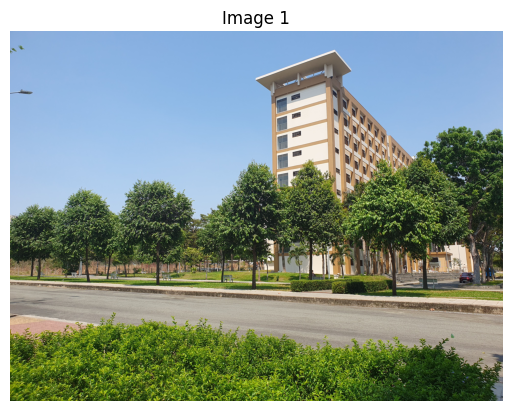

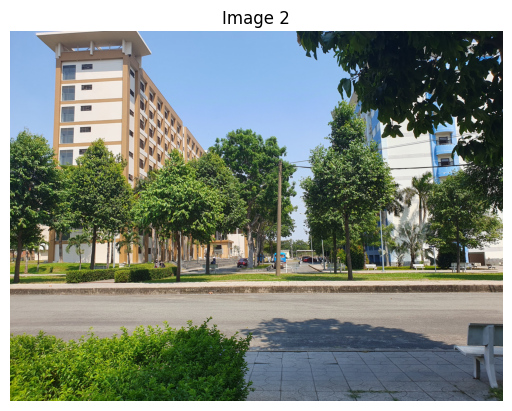

In [2]:
img1 = cv2.imread("20240409_095613.jpg")
img2 = cv2.imread("20240409_095607.jpg")

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.imshow(img1); plt.title("Image 1"); plt.axis("off")
plt.figure()
plt.imshow(img2); plt.title("Image 2"); plt.axis("off")

### Chuyển xám

In [3]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

## FEATURE EXTRACTION

### SIFT

In [8]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

### ORB

In [5]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

## FEATURE MATCHING

In [ ]:
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

## TÍNH HOMOGRAPHY

In [7]:
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\calib3d\src\fundam.cpp:390: error: (-28:Unknown error code -28) The input arrays should have at least 4 corresponding point sets to calculate Homography in function 'cv::findHomography'


## WARP + STITCH

In [ ]:
h2, w2 = img2.shape[:2]

result = cv2.warpPerspective(img1, H, (w2 + img1.shape[1], h2))

result[0:h2, 0:w2] = img2

plt.imshow(result)
plt.title("Panorama")
plt.axis("off")

## BLENDING (cơ bản)

In [ ]:
# simple blending (trung bình)
for i in range(h2):
    for j in range(w2):
        if np.sum(result[i,j]) == 0:
            result[i,j] = img2[i,j]

## SO SÁNH SIFT vs ORB
SIFT
- Chính xác cao
- Match tốt
- Chậm

ORB
- Nhanh
- Nhẹ
- Sai lệch nhiều hơn